In [1]:
# !pip install scikit-learn==1.3.2 imbalanced-learn==0.11.0

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, average_precision_score, PrecisionRecallDisplay, precision_recall_curve
from imblearn.over_sampling import SMOTE
from collections import Counter

## Load data

In [3]:
df2 = pd.read_csv(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.csv") #Local
df2.head(2)

,child_age,child_weight,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,wealth_index,malnurished,province_1.0,province_2.0,province_3.0,province_4.0,province_5.0,province_6.0,province_7.0
0,1,-1.085628,0,0,0,1,5,0,1,1,1,0,0,0,0,0,0
1,3,0.420314,0,1,0,1,5,0,1,1,1,0,0,0,0,0,0


### Train-test split

In [4]:
X = df2.drop(columns=['malnurished'])
y = df2['malnurished']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state=42)


In [5]:
df2['malnurished'].value_counts()

malnurished
0    3535
1    2895
Name: count, dtype: int64

# Logistic Regression

In [6]:
# sm = SMOTE(random_state=42)
# X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
# print('Before SMOTE: ', Counter(y_train))
# print('After SMOTE: ', Counter(y_train_sm))

## Simple model

In [7]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [8]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.77      0.76       707
           1       0.71      0.69      0.70       579

    accuracy                           0.73      1286
   macro avg       0.73      0.73      0.73      1286
weighted avg       0.73      0.73      0.73      1286



### Average Precision Score

In [9]:
y_probas = model.predict_proba(X_test)[:, 1]
print(f'Average Precision: {average_precision_score(y_test, y_probas)}')

Average Precision: 0.7505689832691453


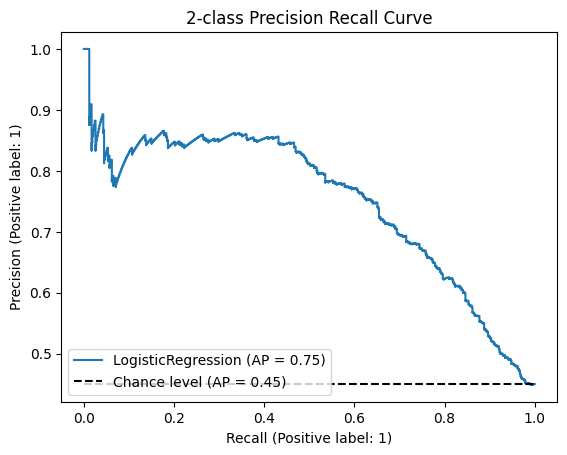

In [10]:
display = PrecisionRecallDisplay.from_estimator(
    model,
    X_test,
    y_test, 
    name="LogisticRegression",
    plot_chance_level = True,
)
display.ax_.set_title('2-class Precision Recall Curve')
plt.show()

### Hyperparameter Tuning

In [11]:
params = [
    {
        'penalty': ['l2'],
        'C': [0.01, 0.1, 1, 10],
        'solver': ['liblinear', 'saga'],
        'class_weight': [None, 'balanced'],
        'max_iter': [100, 500, 1000]
    },
    {
        'penalty': ['l1'],
        'C': [0.01, 0.1, 1, 10],
        'solver': ['liblinear', 'saga'],
        'class_weight': [None, 'balanced'],
        'max_iter': [100, 500, 1000]
    },
    {
        'penalty': ['elasticnet'],
        'C': [0.01, 0.1, 1, 10],
        'solver': ['saga'],
        'class_weight': [None, 'balanced'],
        'l1_ratio': [0.1, 0.5, 0.9],  # required for elasticnet
        'max_iter': [100, 500, 1000]
    }
]

lr_params = LogisticRegression(random_state=42)

grid_search = GridSearchCV(
    estimator=lr_params,
    param_grid=params,
    cv=5,
    scoring='recall',
    verbose=1,
    n_jobs=2
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 168 candidates, totalling 840 fits


GridSearchCV(cv=5, estimator=LogisticRegression(random_state=42), n_jobs=2,
             param_grid=[{'C': [0.01, 0.1, 1, 10],
                          'class_weight': [None, 'balanced'],
                          'max_iter': [100, 500, 1000], 'penalty': ['l2'],
                          'solver': ['liblinear', 'saga']},
                         {'C': [0.01, 0.1, 1, 10],
                          'class_weight': [None, 'balanced'],
                          'max_iter': [100, 500, 1000], 'penalty': ['l1'],
                          'solver': ['liblinear', 'saga']},
                         {'C': [0.01, 0.1, 1, 10],
                          'class_weight': [None, 'balanced'],
                          'l1_ratio': [0.1, 0.5, 0.9],
                          'max_iter': [100, 500, 1000],
                          'penalty': ['elasticnet'], 'solver': ['saga']}],
             scoring='recall', verbose=1)

In [12]:
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Best Parameters: {'C': 0.1, 'class_weight': 'balanced', 'max_iter': 100, 'penalty': 'l2', 'solver': 'liblinear'}
Best Cross-Validation Accuracy: 0.7500037238400239


In [13]:

lr_tune = grid_search.best_estimator_
y_pred = lr_tune.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.69      0.73       707
           1       0.67      0.75      0.71       579

    accuracy                           0.72      1286
   macro avg       0.72      0.72      0.72      1286
weighted avg       0.72      0.72      0.72      1286



In [18]:
y_probas_tune = lr_tune.predict_proba(X_test)[:, 1]
print(f'Average Precision: {average_precision_score(y_test, y_probas_tune)}')

Average Precision: 0.745598644477988


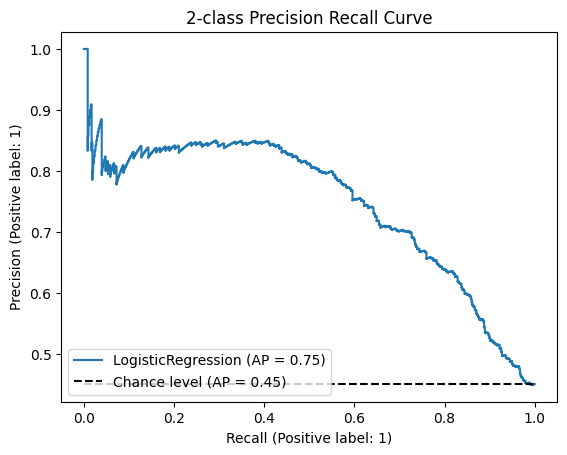

In [19]:
display = PrecisionRecallDisplay.from_estimator(
    lr_tune,
    X_test,
    y_test, 
    name="LogisticRegression",
    plot_chance_level = True,
)
display.ax_.set_title('2-class Precision Recall Curve')
plt.show()

### Confusion matrix

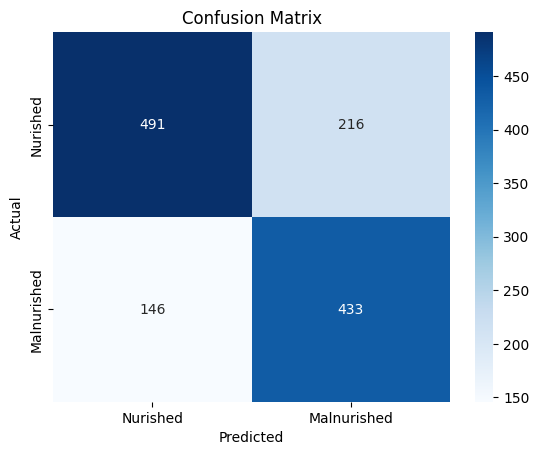

In [16]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Nurished', 'Malnurished'], yticklabels=['Nurished', 'Malnurished'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Features importance

In [20]:
feature_names = X_train.columns

# Get coefficients
coefficients = lr_tune.coef_[0]

# Create a DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Importance (abs)': np.abs(coefficients)
})

# Sort by importance
importance_df = importance_df.sort_values(by='Importance (abs)', ascending=False)
print(importance_df)

                   Feature  Coefficient  Importance (abs)
1             child_weight    -1.757779          1.757779
0                child_age     1.052810          1.052810
9             province_1.0    -0.485509          0.485509
11            province_3.0    -0.388995          0.388995
5                child_sex     0.348453          0.348453
12            province_4.0    -0.347663          0.347663
7         health_insurance    -0.338927          0.338927
13            province_5.0    -0.234191          0.234191
15            province_7.0    -0.168204          0.168204
4                     area    -0.146860          0.146860
10            province_2.0    -0.121048          0.121048
2   diarrhoea_last_2_weeks     0.078215          0.078215
8             wealth_index    -0.069852          0.069852
6         mother_education    -0.061984          0.061984
3       fever_last_2_weeks    -0.040611          0.040611
14            province_6.0     0.006465          0.006465


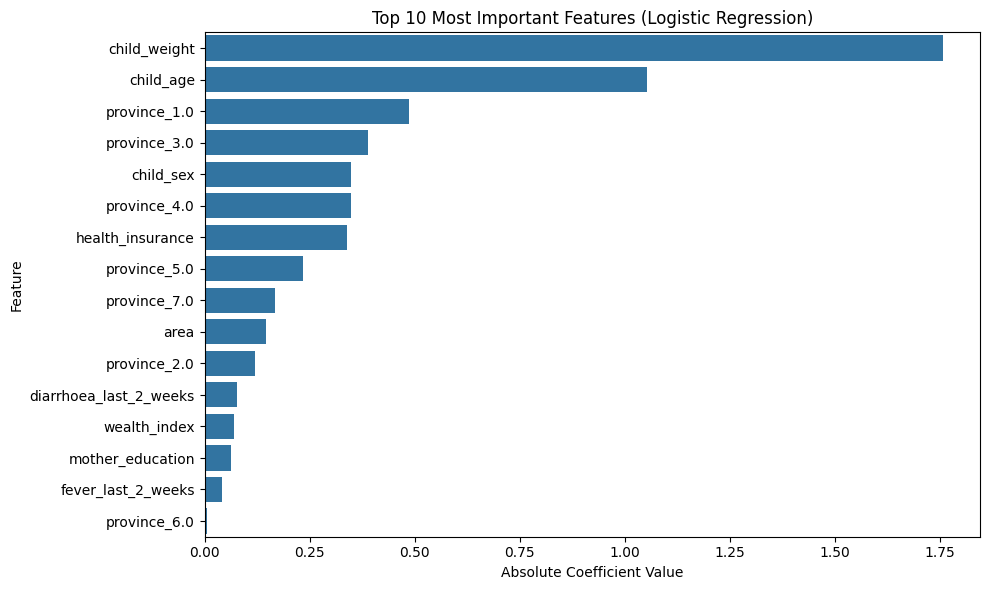

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x='Importance (abs)', y='Feature', data=importance_df.head(17))
plt.title("Top 10 Most Important Features (Logistic Regression)")
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Additional

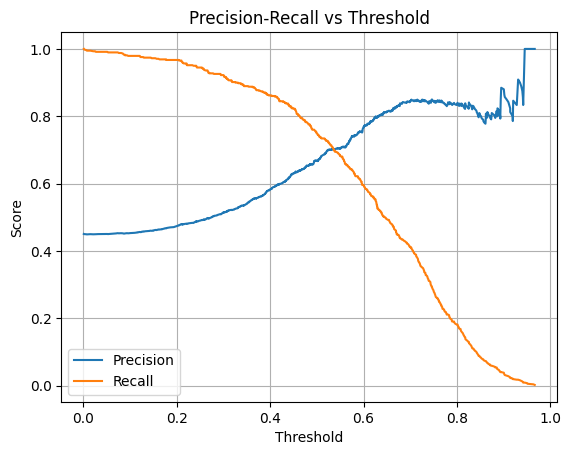

In [21]:
y_probas = lr_tune.predict_proba(X_test)[:, 1]       #Probabilities for class 1
precision, recall, thresholds = precision_recall_curve(y_test, y_probas)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.grid()
plt.legend()
plt.show()

In [22]:
# Apply custom threshold
y_probas_custom = (y_probas >= 0.40).astype(int)
print(f'Classification Report: \n{classification_report(y_test, y_probas_custom)}\n')

Classification Report: 
              precision    recall  f1-score   support

           0       0.81      0.50      0.62       707
           1       0.58      0.86      0.70       579

    accuracy                           0.66      1286
   macro avg       0.70      0.68      0.66      1286
weighted avg       0.71      0.66      0.65      1286


